# DMP Bridge — Model Comparison (Docling extractor)

Comparing three LLM models on structured DMP extraction quality using the **Docling** PDF extractor, scored **two ways**:

- **Path A** — against the original ("old") manually-labeled ground truth
- **Path B** — against the newer annotation standard, via an annotation-conversion rule

**Samples:** 3–10 (8 documents; samples 1 & 2 excluded — used for prompt development)

## Setup

In [1]:
from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old,
    micro_prf1, compute_f1_rows, confusion_matrix_df,
)
from dmpbridge.evaluation.annotation_rules import (
    convert_tag_to_final,
    load_method_new,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

MODELS = [
    ("llama3.1:8b",  "llama3.1-8b_docling_whole_doc"),
    ("llama3.3:70b", "llama3.3-70b_docling_whole_doc"),
    ("gemma4:e4b",   "gemma4-e4b_docling_whole_doc"),
]
EXCLUDE = [1, 2]
COLORS  = ['#1d4ed8', '#60a5fa', '#34d399']
metrics = ['precision', 'recall', 'f1']
metric_labels = ['Precision', 'Recall', 'F1']

---
# Path A — Evaluation against the OLD annotation

Structured JSON scored directly against `data/input/ground_truth_old_version/` — no conversion step.

In [2]:
results_a = {}
summary_a_rows = []
for display_name, tag in MODELS:
    df, conf, errs = load_method_old(tag, exclude=EXCLUDE)
    if df is None:
        print(f'{display_name:15s} : no data yet — run scripts/run_docling.ps1 first')
        continue
    results_a[display_name] = {'df': df, 'conf': conf, 'tag': tag}
    m = micro_prf1(conf)
    summary_a_rows.append({'model': display_name, **m})

if not summary_a_rows:
    raise SystemExit('No docling results found. Run scripts/run_docling.ps1 first.')

summary_a = pd.DataFrame(summary_a_rows).set_index('model')

print(f"{'Model':<15}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
print('-' * 46)
for name, row in summary_a.iterrows():
    print(f"{name:<15}  {row['precision']*100:>9.1f}%  {row['recall']*100:>7.1f}%  {row['f1']*100:>7.1f}%")

llama3.3:70b    : no data yet — run scripts/run_docling.ps1 first
Model             Precision    Recall        F1
----------------------------------------------
llama3.1:8b           71.4%     66.7%     69.0%
gemma4:e4b            86.1%     68.9%     76.5%


## Path A: Overall Comparison

Precision drops when a model over-generates spurious blocks; recall drops when it misses gold items. **F1 balances both — this is the single number to compare models on.**

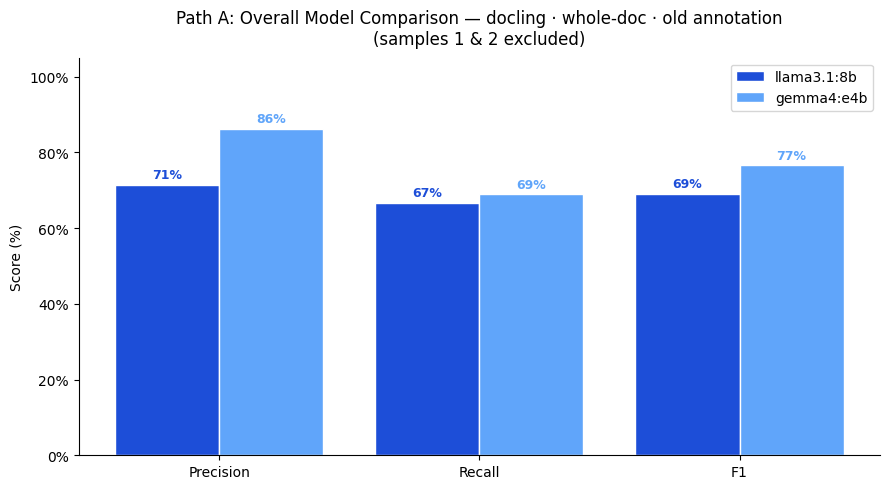

In [3]:
n_models = len(summary_a)
w = 0.8 / n_models
xi = range(len(metrics))

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(summary_a.index, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    vals = [summary_a.loc[name, m] * 100 for m in metrics]
    bars = ax.bar([x + offset for x in xi], vals, width=w,
                  label=name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.0f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 105)
ax.set_ylabel('Score (%)')
ax.set_title('Path A: Overall Model Comparison — docling · whole-doc · old annotation\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Path A Detail: F1 Score per Label

Label                        llama3.1:8b     gemma4:e4b
-------------------------------------------------------
title                              75.0%          93.3%
section.title                      78.7%          86.7%
section.description                66.7%          80.0%
question.text                       0.0%           0.0%
answer.text                        76.1%          73.5%


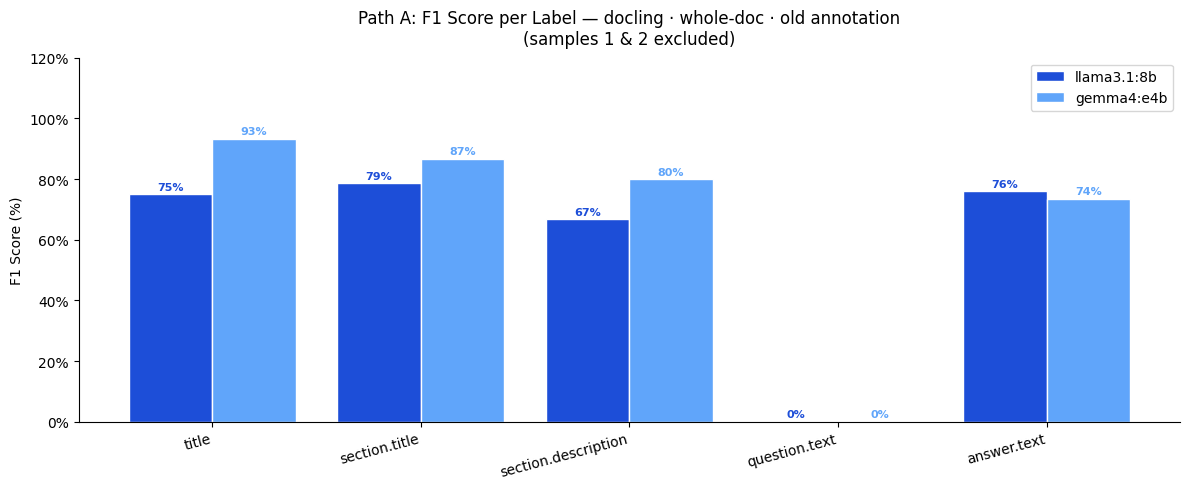

In [4]:
f1_data_a = {}
for name, res in results_a.items():
    f1_data_a[name] = compute_f1_rows(res['conf']).set_index('label')['f1']

df_f1_a = pd.DataFrame(f1_data_a) * 100

print(f"{'Label':<25}" + ''.join(f'{n:>15}' for n in df_f1_a.columns))
print('-' * (25 + 15 * len(df_f1_a.columns)))
for label, row in df_f1_a.iterrows():
    print(f'{label:<25}' + ''.join(f'{v:>14.1f}%' for v in row))

n_models = len(df_f1_a.columns)
n_labels = len(df_f1_a)
w = 0.8 / n_models
xi = range(n_labels)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(df_f1_a.columns, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar([x + offset for x in xi], df_f1_a[name], width=w,
                  label=name, color=color, edgecolor='white')
    for bar, val in zip(bars, df_f1_a[name]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(df_f1_a.index, rotation=15, ha='right')
ax.set_ylim(0, 120)
ax.set_ylabel('F1 Score (%)')
ax.set_title('Path A: F1 Score per Label — docling · whole-doc · old annotation\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Path A Detail: Confusion Matrix per Model
Rows = true label · Columns = predicted label

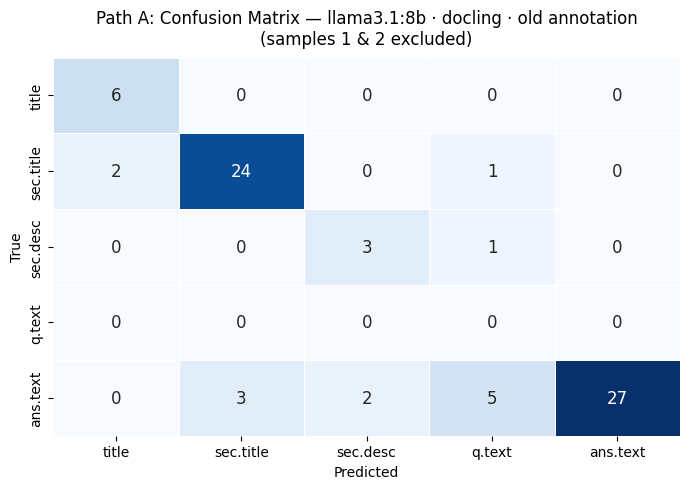

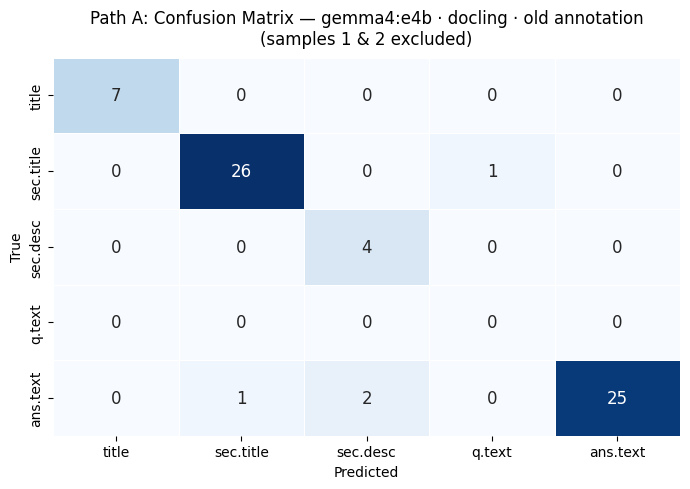

In [5]:
for name, res in results_a.items():
    mat = confusion_matrix_df(res['conf']).drop(columns=['missed'])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
                linecolor='white', ax=ax, cbar=False, annot_kws={'size': 12})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Path A: Confusion Matrix — {name} · docling · old annotation\n(samples 1 & 2 excluded)', pad=10)
    plt.tight_layout()
    plt.show()

---
# Path B — Evaluation against the NEW annotation

Step 1: apply the annotation-conversion rule to every model's structured JSON, producing "final JSON". Step 2: score that final JSON against `data/input/ground_truth_new_version/`.

In [6]:
for _, tag in MODELS:
    n = convert_tag_to_final(tag)
    print(f'{tag:<38} {n} file(s) -> final JSON')

llama3.1-8b_docling_whole_doc          10 file(s) -> final JSON


llama3.3-70b_docling_whole_doc         0 file(s) -> final JSON
gemma4-e4b_docling_whole_doc           10 file(s) -> final JSON


In [7]:
results_b = {}
summary_b_rows = []
for display_name, tag in MODELS:
    df, conf, errs = load_method_new(tag, exclude=EXCLUDE)
    if df is None:
        print(f'{display_name:15s} : no data yet')
        continue
    results_b[display_name] = {'df': df, 'conf': conf, 'tag': tag}
    m = micro_prf1(conf)
    summary_b_rows.append({'model': display_name, **m})

summary_b = pd.DataFrame(summary_b_rows).set_index('model')

print(f"{'Model':<15}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")
print('-' * 46)
for name, row in summary_b.iterrows():
    print(f"{name:<15}  {row['precision']*100:>9.1f}%  {row['recall']*100:>7.1f}%  {row['f1']*100:>7.1f}%")

llama3.3:70b    : no data yet
Model             Precision    Recall        F1
----------------------------------------------
llama3.1:8b           66.7%     70.9%     68.7%
gemma4:e4b            88.9%     81.0%     84.8%


## Path B: Overall Comparison

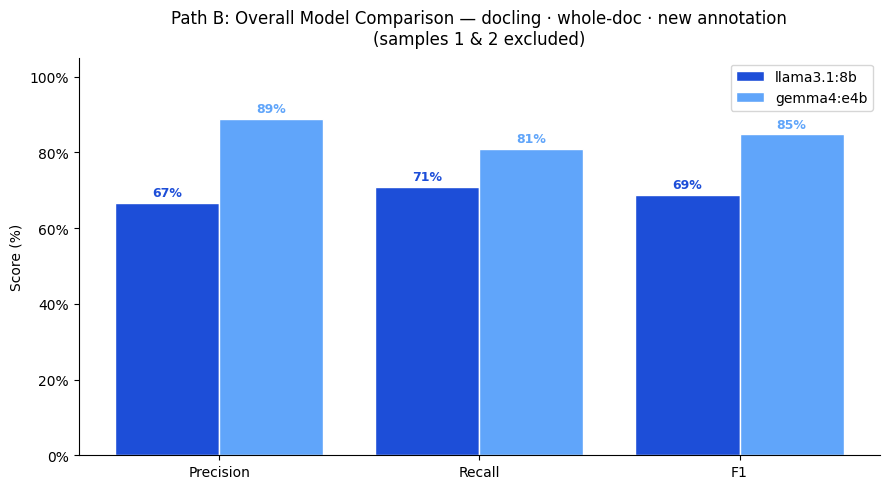

In [8]:
n_models = len(summary_b)
w = 0.8 / n_models
xi = range(len(metrics))

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(summary_b.index, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    vals = [summary_b.loc[name, m] * 100 for m in metrics]
    bars = ax.bar([x + offset for x in xi], vals, width=w,
                  label=name, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v:.0f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 105)
ax.set_ylabel('Score (%)')
ax.set_title('Path B: Overall Model Comparison — docling · whole-doc · new annotation\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Path B Detail: F1 Score per Label

Label                        llama3.1:8b     gemma4:e4b
-------------------------------------------------------
title                              66.7%          80.0%
section.title                      78.7%          90.0%
section.description                66.7%          80.0%
question.text                      26.7%          50.0%
answer.text                        69.7%          85.7%


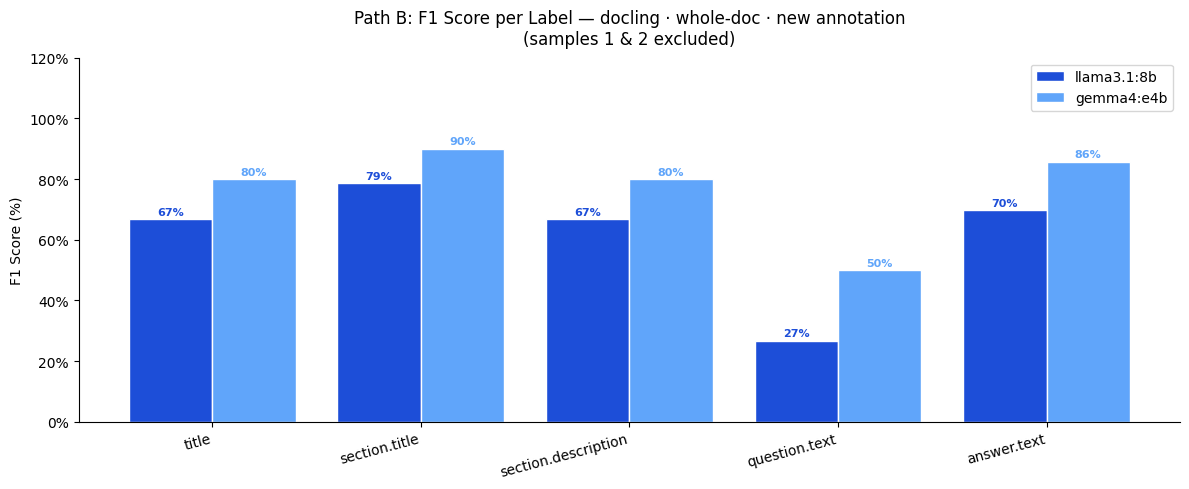

In [9]:
f1_data_b = {}
for name, res in results_b.items():
    f1_data_b[name] = compute_f1_rows(res['conf']).set_index('label')['f1']

df_f1_b = pd.DataFrame(f1_data_b) * 100

print(f"{'Label':<25}" + ''.join(f'{n:>15}' for n in df_f1_b.columns))
print('-' * (25 + 15 * len(df_f1_b.columns)))
for label, row in df_f1_b.iterrows():
    print(f'{label:<25}' + ''.join(f'{v:>14.1f}%' for v in row))

n_models = len(df_f1_b.columns)
n_labels = len(df_f1_b)
w = 0.8 / n_models
xi = range(n_labels)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(df_f1_b.columns, COLORS[:n_models])):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar([x + offset for x in xi], df_f1_b[name], width=w,
                  label=name, color=color, edgecolor='white')
    for bar, val in zip(bars, df_f1_b[name]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8,
                fontweight='bold', color=color)

ax.set_xticks(list(xi))
ax.set_xticklabels(df_f1_b.index, rotation=15, ha='right')
ax.set_ylim(0, 120)
ax.set_ylabel('F1 Score (%)')
ax.set_title('Path B: F1 Score per Label — docling · whole-doc · new annotation\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Path B Detail: Confusion Matrix per Model
Rows = true label · Columns = predicted label

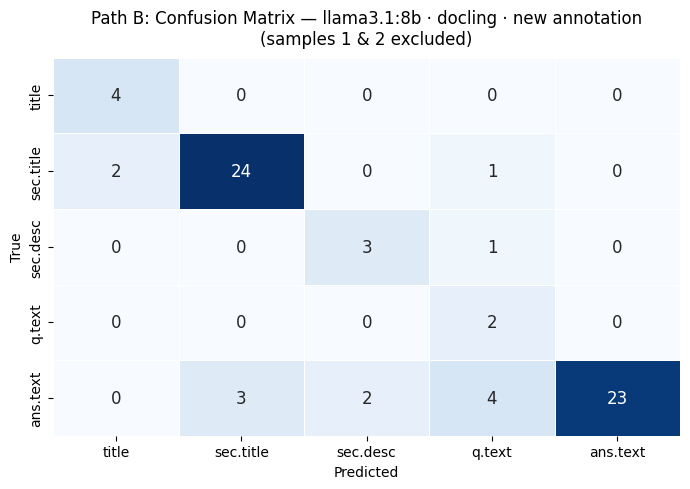

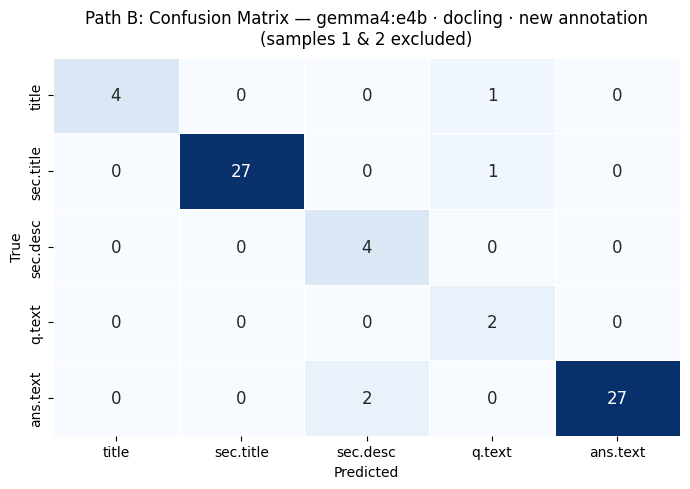

In [10]:
for name, res in results_b.items():
    mat = confusion_matrix_df(res['conf']).drop(columns=['missed'])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
                linecolor='white', ax=ax, cbar=False, annot_kws={'size': 12})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Path B: Confusion Matrix — {name} · docling · new annotation\n(samples 1 & 2 excluded)', pad=10)
    plt.tight_layout()
    plt.show()

---
# Path A vs Path B — Side by Side

Same models, same predictions — the only difference is which ground truth (and whether the annotation-conversion rule was applied) they're scored against.

Model              F1 (old)    F1 (new)
----------------------------------------
llama3.1:8b           69.0%       68.7%
gemma4:e4b            76.5%       84.8%


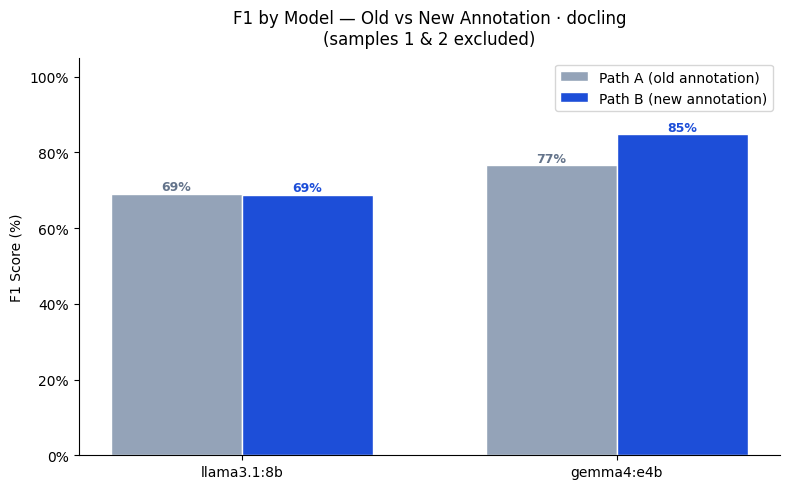

In [11]:
compare_rows = []
for display_name, _ in MODELS:
    if display_name in summary_a.index and display_name in summary_b.index:
        compare_rows.append({
            'model': display_name,
            'F1 (Path A: old)': summary_a.loc[display_name, 'f1'] * 100,
            'F1 (Path B: new)': summary_b.loc[display_name, 'f1'] * 100,
        })
compare_df = pd.DataFrame(compare_rows).set_index('model')

print(f"{'Model':<15}  {'F1 (old)':>10}  {'F1 (new)':>10}")
print('-' * 40)
for name, row in compare_df.iterrows():
    print(f"{name:<15}  {row['F1 (Path A: old)']:>9.1f}%  {row['F1 (Path B: new)']:>9.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
xi = range(len(compare_df))
w = 0.35
ax.bar([x - w/2 for x in xi], compare_df['F1 (Path A: old)'], width=w,
       label='Path A (old annotation)', color='#94a3b8', edgecolor='white')
ax.bar([x + w/2 for x in xi], compare_df['F1 (Path B: new)'], width=w,
       label='Path B (new annotation)', color='#1d4ed8', edgecolor='white')
for x, (old, new) in enumerate(zip(compare_df['F1 (Path A: old)'], compare_df['F1 (Path B: new)'])):
    ax.text(x - w/2, old + 1, f'{old:.0f}%', ha='center', fontsize=9, fontweight='bold', color='#64748b')
    ax.text(x + w/2, new + 1, f'{new:.0f}%', ha='center', fontsize=9, fontweight='bold', color='#1d4ed8')
ax.set_xticks(list(xi))
ax.set_xticklabels(compare_df.index)
ax.set_ylim(0, 105)
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 by Model — Old vs New Annotation · docling\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()